# E2 — Análisis exploratorio y preprocesamiento

Los datos que se analizarán y prepararán pertenecen a la ENSANUT Continua 2024. Estos datos contienen información sobre la salud y nutrición de la población de los 32 estados de México durante el periodo 2024. Los datos provienen de la siguiente fuente:

https://ensanut.insp.mx/encuestas/ensanutcontinua2024/descargas.php

### Carga de los archivos

 Sube los dos archivos siguientes:
1. adultos_ensanut2024_w.dta
2. antropometria_ensanut2024_w.csv

## Importar librerias


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SEMILLA = 42                        # semilla fija = resultados reproducibles
np.random.seed(SEMILLA)

## Carga y union de los datos


### Paso 1. Lista de variables que se usaran

Del cuestionario de adultos se seleccionan solo las variables que tienen sentido como factores de riesgo. Esto quiere decir que se excluye toda la seccion de diabetes (preguntas a03*) porque esas variables son consecuencia de tener la enfermedad, solo existen para quien ya fue diagnosticado. En caso de ser usadas el modelo tendria fuga de datos.

In [27]:
# Variables predictoras: demograficas, sintomas, comorbilidades, antecedentes y habitos.
PRED_ADULTOS = [
    'edad', 'sexo',                                  # demograficas
    'a0107',                                         # cambio de peso (12 meses)
    'a0211', 'a0212', 'a0213', 'a0214',              # escala de sintomas
    'a0215', 'a0216', 'a0217',                       #   depresivos (7 items)
    'a0401',                                         # hipertension diagnosticada
    'a0601a', 'a0601b', 'a0601c',                    # enfermedad renal
    'a0604',                                         # colesterol alto
    'a0606',                                         # trigliceridos altos
    'a0701p', 'a0701m', 'a0701h',                    # familiar con diabetes
    'a0702p', 'a0702m', 'a0702h',                    # familiar con hipertension
    'a1301', 'a1305', 'a1307',                       # tabaquismo
    'a1308',                                         # frecuencia de alcohol
]
OBJETIVO = 'a0301'    # 1=Si, 2=Si gestacional, 3=No

In [28]:
print('Variables predictoras del cuestionario:', len(PRED_ADULTOS))
print('Variable objetivo:', OBJETIVO)

Variables predictoras del cuestionario: 26
Variable objetivo: a0301


### Paso 2. Cargar el cuestionario de adultos

Se lee el archivo .dta (Stata), solo con las variables que nos interesan

In [29]:
adultos = pd.read_stata('adultos_ensanut2024_w.dta', convert_categoricals=False, columns=['FOLIO_INT'] + PRED_ADULTOS + [OBJETIVO])
adultos['FOLIO_INT'] = adultos['FOLIO_INT'].astype(str)
print('Cuestionario de adultos:', adultos.shape)
adultos.head()


Cuestionario de adultos: (12924, 28)


,FOLIO_INT,edad,sexo,a0107,a0211,a0212,a0213,a0214,a0215,a0216,...,a0701m,a0701h,a0702p,a0702m,a0702h,a1301,a1305,a1307,a1308,a0301
0,2024_01001001_02,83.0,2.0,2.0,1.0,2.0,1.0,1.0,1.0,4.0,...,1.0,1.0,1.0,1.0,1.0,3.0,3.0,3.0,4.0,1.0
1,2024_01001001_04,29.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,4.0,...,2.0,2.0,2.0,2.0,2.0,3.0,1.0,3.0,2.0,3.0
2,2024_01001002_01,34.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0,3.0,...,2.0,2.0,2.0,2.0,2.0,3.0,3.0,4.0,3.0,3.0
3,2024_01001004_03,21.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,4.0,...,2.0,2.0,1.0,2.0,2.0,1.0,NaN,2.0,2.0,3.0
4,2024_01001006_02,76.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,4.0,...,2.0,2.0,2.0,1.0,1.0,3.0,3.0,4.0,4.0,3.0


In [30]:
adultos.describe().T

,count,mean,std,min,25%,50%,75%,max
edad,12924.0,46.578691,16.769184,20.0,33.0,45.0,59.0,104.0
sexo,12924.0,1.582792,0.493117,1.0,1.0,2.0,2.0,2.0
a0107,12924.0,2.385562,0.950112,1.0,2.0,3.0,3.0,9.0
a0211,12924.0,1.468044,0.845112,1.0,1.0,1.0,2.0,4.0
a0212,12924.0,1.487929,0.812210,1.0,1.0,1.0,2.0,4.0
a0213,12924.0,1.469901,0.820654,1.0,1.0,1.0,2.0,4.0
a0214,12924.0,1.539539,0.891672,1.0,1.0,1.0,2.0,4.0
a0215,12924.0,1.878211,1.141342,1.0,1.0,1.0,3.0,4.0
a0216,12924.0,3.463015,0.963921,1.0,3.0,4.0,4.0,4.0
a0217,12924.0,1.462628,0.806562,1.0,1.0,1.0,2.0,4.0


### Paso 3. Cargar la antropometria

Es un CSV separado por punto y coma. Tambien usa la coma como separador decimal y deja espacios en blanco para los valores ausentes, asi que primero convertimos todo a numero.


In [31]:
antro = pd.read_csv('antropometria_ensanut2024_w.csv',sep=';', encoding='utf-8-sig', low_memory=False)

for col in antro.columns:
    if col != 'FOLIO_INT':
        antro[col] = pd.to_numeric(
            antro[col].astype(str).str.strip().str.replace(',', '.'),
            errors='coerce')

print('Antropometria:', antro.shape)

Antropometria: (17597, 100)


### Paso 4. Quedarnos solo con las mediciones utiles de antropometria

Cada medida se registra en dos grupos de columnas segun el procedimiento (de pie / acostado). Tomamos la primera que este disponible. La presion arterial se promedia entre la 2a y 3a toma (la 1a se descarta por convencion clinica).


In [32]:
antro_simple = pd.DataFrame()
antro_simple['FOLIO_INT']         = antro['FOLIO_INT'].astype(str)
antro_simple['peso']              = antro['an01_1'].fillna(antro['an12_1'])     # kg
antro_simple['talla']             = antro['an04_1'].fillna(antro['an15_1'])     # cm
antro_simple['cintura']           = antro['an08_1'].fillna(antro['an21_1'])     # cm
antro_simple['imc']               = antro['imc']                                # ya viene calculado
antro_simple['presion_sistolica'] = (antro['an27_02s'] + antro['an27_03s']) / 2
antro_simple['presion_diastolica']= (antro['an27_02d'] + antro['an27_03d']) / 2

print('Antropometria con columnas utiles:', antro_simple.shape)
antro_simple.head()


Antropometria con columnas utiles: (17597, 7)


,FOLIO_INT,peso,talla,cintura,imc,presion_sistolica,presion_diastolica
0,2024_01001001_02,62.15,153.0,222.2,26.55,112.0,78.5
1,2024_01001001_05,38.35,148.4,NaN,17.41,NaN,NaN
2,2024_01001002_01,74.20,171.0,79.0,25.38,129.5,97.5
3,2024_01001002_03,12.20,88.3,NaN,15.65,NaN,NaN
4,2024_01001004_03,58.50,170.0,75.0,20.24,NaN,NaN


In [33]:
antro_simple.describe().T

,count,mean,std,min,25%,50%,75%,max
peso,17449.0,60.504746,28.632597,3.05,43.45,63.25,77.70,222.22
talla,17449.0,148.070720,25.577883,49.10,142.60,154.60,163.30,222.20
cintura,10359.0,110.466686,40.405524,30.80,89.30,98.50,110.40,222.20
imc,17293.0,25.598512,7.393540,7.58,19.47,25.68,30.45,157.69
presion_sistolica,5823.0,123.548515,64.248879,80.00,105.50,116.50,128.50,999.00
presion_diastolica,5823.0,77.288082,65.621680,49.00,64.00,71.50,79.00,999.00


### Paso 5. Unir las dos fuentes

Se hace merge (unir) por el FOLIO_INT. Con how='inner' conservamos solo a las personas que aparecen en ambos archivos.

In [34]:
df = adultos.merge(antro_simple, on='FOLIO_INT', how='inner')
print('Datos unidos:', df.shape)
df.head()


Datos unidos: (9963, 34)


,FOLIO_INT,edad,sexo,a0107,a0211,a0212,a0213,a0214,a0215,a0216,...,a1305,a1307,a1308,a0301,peso,talla,cintura,imc,presion_sistolica,presion_diastolica
0,2024_01001001_02,83.0,2.0,2.0,1.0,2.0,1.0,1.0,1.0,4.0,...,3.0,3.0,4.0,1.0,62.15,153.0,222.2,26.55,112.0,78.5
1,2024_01001002_01,34.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0,3.0,...,3.0,4.0,3.0,3.0,74.20,171.0,79.0,25.38,129.5,97.5
2,2024_01001004_03,21.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,4.0,...,NaN,2.0,2.0,3.0,58.50,170.0,75.0,20.24,NaN,NaN
3,2024_01001007_02,58.0,1.0,2.0,1.0,1.0,2.0,2.0,1.0,4.0,...,3.0,4.0,4.0,3.0,80.00,178.0,90.0,25.25,121.5,76.5
4,2024_01001008_02,73.0,2.0,3.0,1.0,1.0,1.0,1.0,4.0,4.0,...,1.0,4.0,6.0,3.0,79.95,156.3,110.0,32.73,112.5,69.0


### Paso 6. Codificación de la variable objetivo
La pregunta a0301 tiene tres codigos: 1=Si, 2=Si (diabetes gestacional), 3=No.
- 1 : 1 (con diabetes)
- 3 : 0 (sin diabetes)
- 2 : se descarta



In [35]:
df['diabetes'] = df['a0301'].map({1: 1, 3: 0})
df = df[df['diabetes'].notna()].copy()
df['diabetes'] = df['diabetes'].astype(int)
df = df.drop(columns='a0301')
print('Despues de construir el objetivo:', df.shape)

Despues de construir el objetivo: (9945, 34)


Al revisar la distribución de la variable objetivo, se puede observar la un desbalance significativo entre las clases, donde Sí diabetes representa la clase minoritaria.

In [36]:
print('Distribucion de la clase:')
print(df['diabetes'].value_counts())

Distribucion de la clase:
diabetes
0    8610
1    1335
Name: count, dtype: int64


## Limpieza de los datos


### Paso 7. Limpiar codigos de (Sin respuesta)
En las preguntas categoricas, 8 = "No sabe" y 9 = "No responde". Si los dejaramos como numeros el modelo los interpretaria como una categoria valida por lo que se convierten a NaN.


In [37]:
CATEGORICAS = ['a0107', 'a0401', 'a0601a', 'a0601b', 'a0601c', 'a0604',
               'a0606', 'a0701p', 'a0701m', 'a0701h', 'a0702p', 'a0702m',
               'a0702h', 'a1301', 'a1305', 'a1307', 'a1308']
DEPRESION = ['a0211', 'a0212', 'a0213', 'a0214', 'a0215', 'a0216', 'a0217']

for col in CATEGORICAS + DEPRESION:
    df[col] = df[col].where(~df[col].isin([8, 9]), np.nan)


### Paso 8. Detectar Outliers

Algunas variables tienen posible errores al ser capturados (por ejemplo un IMC muy bajo o una estatura demasiado baja). Los miramos con diagramas de caja.

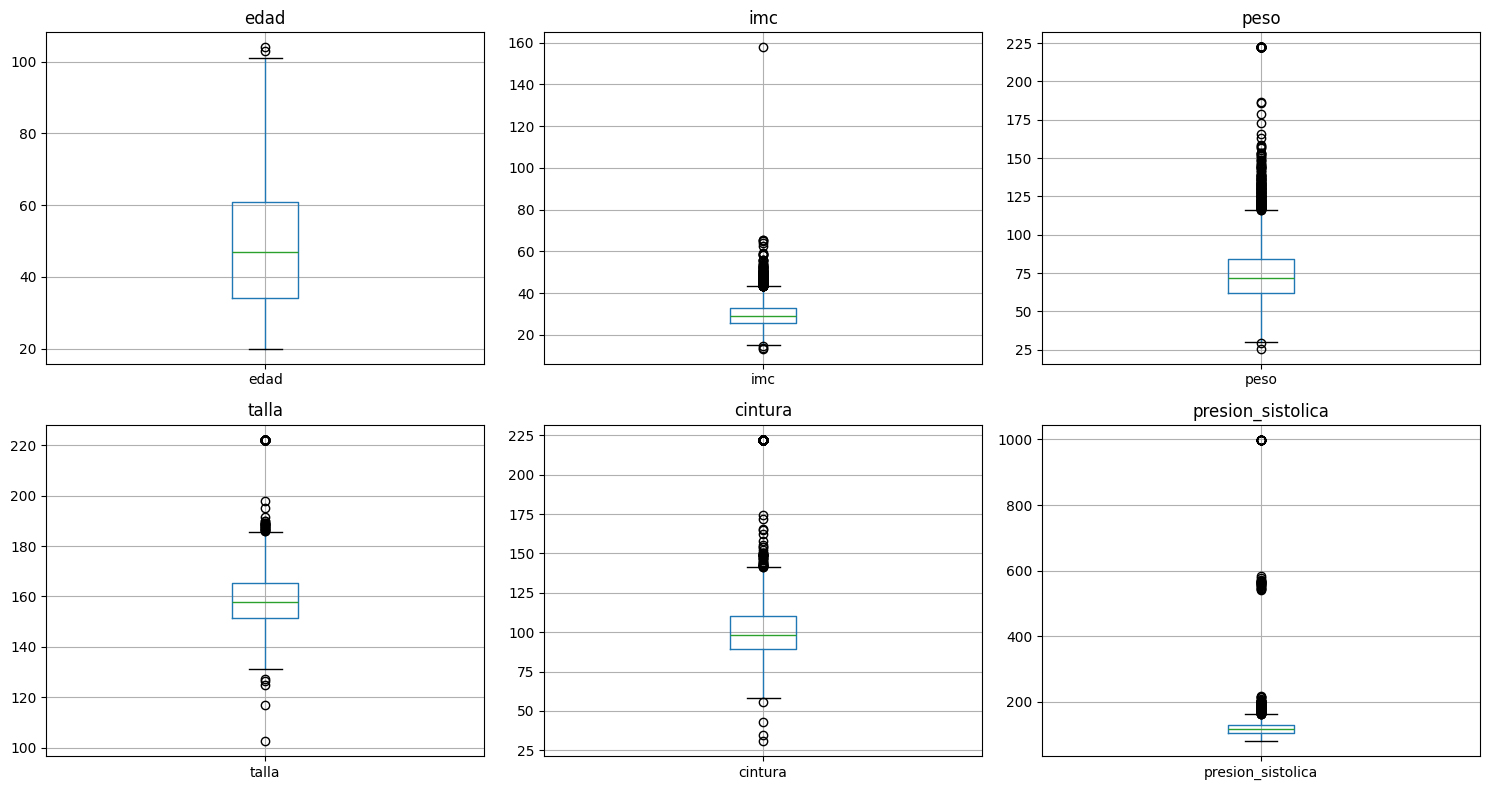

In [38]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, ['edad', 'imc', 'peso', 'talla', 'cintura', 'presion_sistolica']):
    df.boxplot(column=col, ax=ax); ax.set_title(col)
plt.tight_layout(); plt.show()


### Paso 9. Corregir los valores fuera de rango

Definimos un rango clinicamente posible para cada variable y convertimos a NaN los valores que se salen. No eliminamos el registro completo para no perder el resto de su informacion.


In [39]:
RANGOS = {
    'imc'              : (12, 70),
    'peso'             : (25, 250),
    'talla'            : (120, 210),
    'cintura'          : (40, 200),
    'presion_sistolica' : (70, 250),
    'presion_diastolica': (40, 150),
}

for col, (minimo, maximo) in RANGOS.items():
    fuera = (~df[col].between(minimo, maximo)) & df[col].notna()
    df.loc[fuera, col] = np.nan

### Paso 10. Revision de calidad: faltantes y duplicados


In [40]:
faltantes = df.isna().sum()
faltantes = faltantes[faltantes > 0].sort_values(ascending=False)
print('Variables con valores faltantes:')
print(faltantes)

Variables con valores faltantes:
presion_diastolica    4630
presion_sistolica     4630
a1305                 1503
cintura               1391
a0702h                 843
a0701h                 724
a0702p                 522
a0701p                 389
a0702m                 230
imc                    219
talla                  215
a0701m                 172
peso                   114
a0107                   58
a1307                   14
a1301                   13
a1308                    3
dtype: int64


In [41]:
print('Filas duplicadas:', df.duplicated().sum())

Filas duplicadas: 0


## EDA


### Grafica 1. Distribucion de la variable objetivo


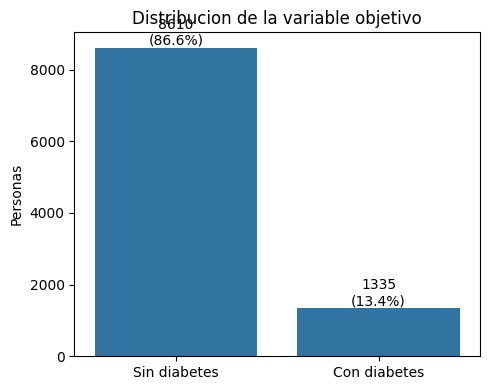

In [42]:
plt.figure(figsize=(5, 4))
conteo = df['diabetes'].value_counts().sort_index()
sns.barplot(x=['Sin diabetes', 'Con diabetes'], y=conteo.values)
for i, v in enumerate(conteo.values):
    plt.text(i, v, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', va='bottom')
plt.title('Distribucion de la variable objetivo')
plt.ylabel('Personas'); plt.tight_layout(); plt.show()


En la gráfica se puede notar un gran desbalance, en donde solo 13% tiene diabetes.

### Grafica 2. Edad segun diagnostico de diabetes


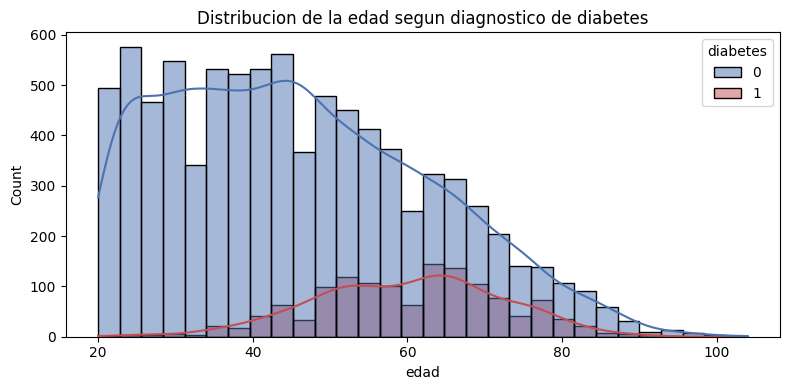

In [43]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='edad', hue='diabetes', bins=30, kde=True,
             palette=['#4C72B0', '#C44E52'])
plt.title('Distribucion de la edad segun diagnostico de diabetes')
plt.tight_layout(); plt.show()


  Se puede notar que la diabetes se concentra claramente en edades mayores: el grupo con diabetes se desplaza hacia la derecha.


### Grafica 3. IMC y cintura segun diagnostico


/tmp/ipykernel_583/4034458191.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_title('IMC segun diabetes'); axes[0].set_xticklabels(['No', 'Si'])
/tmp/ipykernel_583/4034458191.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_title('Cintura segun diabetes'); axes[1].set_xticklabels(['No', 'Si'])


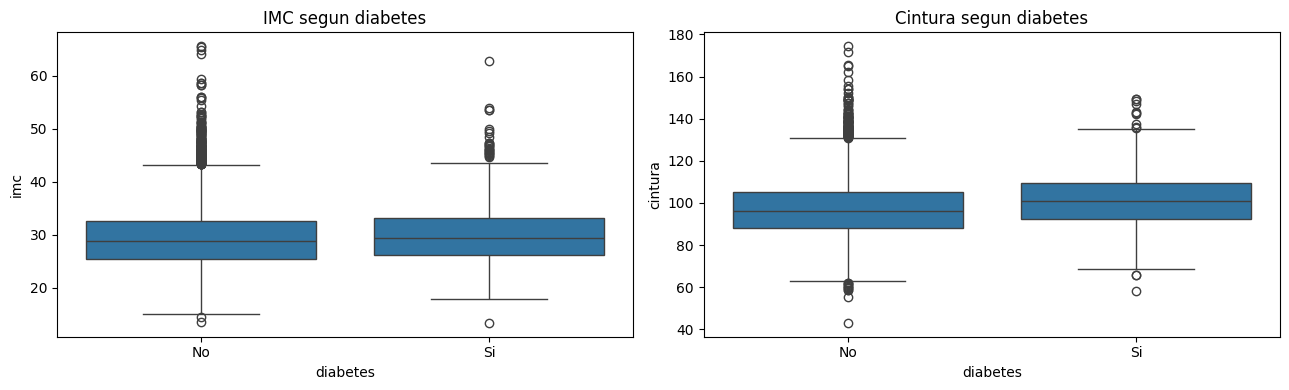

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(data=df, x='diabetes', y='imc', ax=axes[0])
axes[0].set_title('IMC segun diabetes'); axes[0].set_xticklabels(['No', 'Si'])
sns.boxplot(data=df, x='diabetes', y='cintura', ax=axes[1])
axes[1].set_title('Cintura segun diabetes'); axes[1].set_xticklabels(['No', 'Si'])
plt.tight_layout(); plt.show()


En la gráfica se puede notar que ambos, el IMC y la cintura tienden a ser mayores en las personas con diabetes (obesidad).


### Grafica 4. Antecedente familiar de diabetes


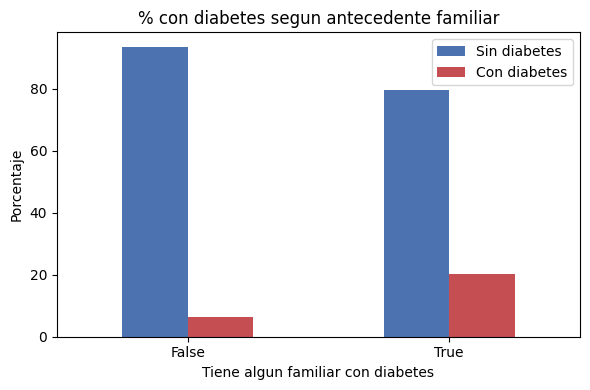

In [45]:
tiene_antecedente = df[['a0701p', 'a0701m', 'a0701h']].apply(
    lambda fila: (fila == 1).any(), axis=1)
tabla = pd.crosstab(tiene_antecedente, df['diabetes'], normalize='index') * 100
tabla.plot(kind='bar', figsize=(6, 4), color=['#4C72B0', '#C44E52'])
plt.title('% con diabetes segun antecedente familiar')
plt.xlabel('Tiene algun familiar con diabetes')
plt.ylabel('Porcentaje')
plt.legend(['Sin diabetes', 'Con diabetes'])
plt.xticks(rotation=0); plt.tight_layout(); plt.show()


En la gráfica se puede notar que las personas con antecedentes familiares de diabetes presentan una proporcion notablemente mayor de la enfermedad.

### Grafica 5. Hipertension


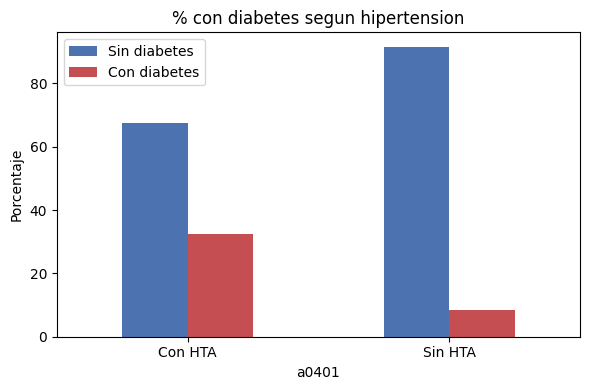

In [46]:
hta = df['a0401'].map({1: 'Con HTA', 2: 'Sin HTA', 3: 'Sin HTA'})
tabla = pd.crosstab(hta, df['diabetes'], normalize='index') * 100
tabla.plot(kind='bar', figsize=(6, 4), color=['#4C72B0', '#C44E52'])
plt.title('% con diabetes segun hipertension')
plt.ylabel('Porcentaje'); plt.legend(['Sin diabetes', 'Con diabetes'])
plt.xticks(rotation=0); plt.tight_layout(); plt.show()


En la gráfica se puede ver que la hipertension se puede encontrar mas en las personas con diabetes.

### Grafica 6. Matriz de correlacion


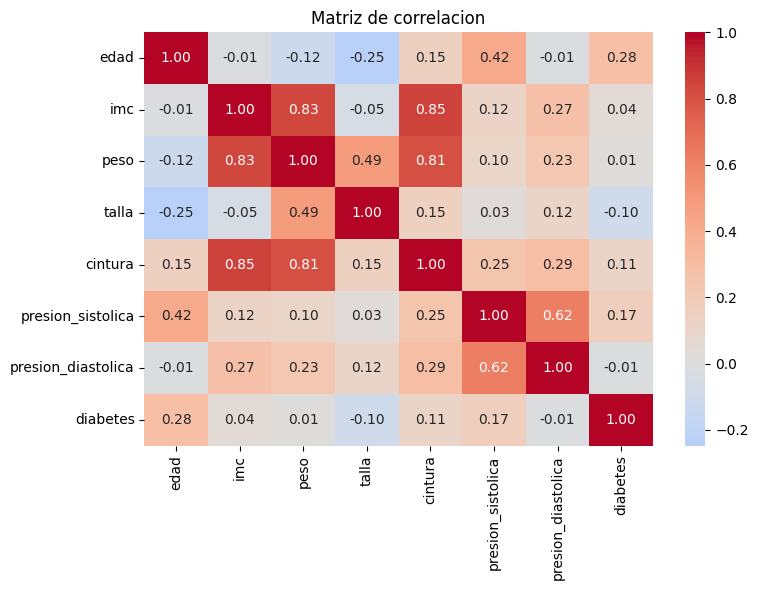

In [47]:
numericas = df[['edad', 'imc', 'peso', 'talla', 'cintura',
                'presion_sistolica', 'presion_diastolica', 'diabetes']]
plt.figure(figsize=(8, 6))
sns.heatmap(numericas.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de correlacion'); plt.tight_layout(); plt.show()


Se puede notar como la edad y presion_sistolica presentan la mayor correlación positiva con la diabetes.


## Preparacion final del dataset para el modelado


### Paso 11. Construir las variables finales para el modelado

Se genera un nuevo dataframe proc que solo contiene variables numericas listas para alimentar a un modelo.

In [48]:
proc = pd.DataFrame(index=df.index)
proc['diabetes'] = df['diabetes']

# Variables numericas
proc['edad']               = df['edad']
proc['imc']                = df['imc']
proc['peso']               = df['peso']
proc['talla']              = df['talla']
proc['cintura']            = df['cintura']
proc['presion_sistolica']  = df['presion_sistolica']
proc['presion_diastolica'] = df['presion_diastolica']

# Sexo: 2 = mujer (1) y 1 = hombre (0)
proc['mujer'] = (df['sexo'] == 2).astype(int)


In [49]:
# Indice de sintomas depresivos
# Se suman los 7 reactivos de la escala. El item a0216 ('disfruto de la vida') va en sentido inverso, asi que lo invertimos con 5 - valor.
proc['indice_depresion'] = (
    df['a0211'] + df['a0212'] + df['a0213'] + df['a0214'] +
    df['a0215'] + (5 - df['a0216']) + df['a0217'])


In [50]:
# Conteo de familiares con una condicion
proc['n_familiares_diabetes']     = (df[['a0701p','a0701m','a0701h']] == 1).sum(axis=1)
proc['n_familiares_hipertension'] = (df[['a0702p','a0702m','a0702h']] == 1).sum(axis=1)


In [51]:
# Variables binarias
proc['hipertension']         = df['a0401'].map({1: 1, 2: 0})
proc['colesterol_alto']      = df['a0604'].map({1: 1, 2: 0})
proc['trigliceridos_altos']  = df['a0606'].map({1: 1, 2: 0})
proc['enf_renal_a']          = df['a0601a'].map({1: 1, 2: 0})
proc['enf_renal_b']          = df['a0601b'].map({1: 1, 2: 0})
proc['enf_renal_c']          = df['a0601c'].map({1: 1, 2: 0})


In [52]:
# Tabaquismo y alcohol
# a1301: 1=fuma diario, 2=algunos dias, 3=no fuma. Lo convertimos a binario
proc['fuma_actualmente'] = df['a1301'].map({1: 1, 2: 1, 3: 0})
proc['fumo_en_pasado']   = df['a1305'].map({1: 1, 2: 0})
# a1308: 1=diario - 6=nunca. Lo invertimos para que mayor valor = mayor consumo
proc['consumo_alcohol']  = 7 - df['a1308']


In [53]:
# Cambio reciente de peso
proc['gano_peso']   = (df['a0107'] == 1).astype(int)
proc['perdio_peso'] = (df['a0107'] == 2).astype(int)

print('Dataset procesado:', proc.shape)
proc.head()


Dataset procesado: (9945, 23)


,diabetes,edad,imc,peso,talla,cintura,presion_sistolica,presion_diastolica,mujer,indice_depresion,...,colesterol_alto,trigliceridos_altos,enf_renal_a,enf_renal_b,enf_renal_c,fuma_actualmente,fumo_en_pasado,consumo_alcohol,gano_peso,perdio_peso
0,1,83.0,26.55,62.15,153.0,NaN,112.0,78.5,1,8.0,...,0,0,0,0,0,0.0,NaN,3.0,0,1
1,0,34.0,25.38,74.20,171.0,79.0,129.5,97.5,0,9.0,...,0,0,0,0,0,0.0,NaN,4.0,1,0
2,0,21.0,20.24,58.50,170.0,75.0,NaN,NaN,0,7.0,...,0,1,1,0,0,1.0,NaN,5.0,1,0
3,0,58.0,25.25,80.00,178.0,90.0,121.5,76.5,0,9.0,...,1,0,0,0,1,0.0,NaN,3.0,0,1
4,0,73.0,32.73,79.95,156.3,110.0,112.5,69.0,1,10.0,...,0,0,1,0,0,0.0,1.0,1.0,0,0


### Paso 12. Guardar el dataset principal

Se guarda en formato CSV. Este archivo se utilizara para los modelos

In [54]:
proc.to_csv('mineria_principal.csv', index=False)

## Dataset enriquecido

En esta parte se construye un dataset mas rico en datos, el cual contiene:
- actividad fisica (horas de sueño, dias de actividad, horas sentado).
- Encuestas de sangres (hemoglobina, ferritina, vitamina B12, vitamina D).

Se separo del dataset principal ya que tiene menos registros. La razón de esto es que no todas las personas tienen esas mediciones, pero añade mas variables clinicas que podrian mejorar la predicción.

### Paso 13. Subir los archivos extra


Sube los tres archivos adicionales para el dataset enriquecido:
1. actividad_fisica_ensanut2024_w-adultos.csv
2. sangre_hemoglobina_ensanut2024_w.csv
3. ensasangre24.determinaciones_micronutrimentos.csv

### Paso 14. Cargar el modulo de actividad fisica


In [55]:
actividad = pd.read_csv('actividad_fisica_ensanut2024_w-adultos.csv', sep=';', encoding='utf-8-sig', low_memory=False)
actividad['FOLIO_INT'] = actividad['FOLIO_INT'].astype(str)

# Tomamos solo las cinco variables resumen que nos interesan.
act_simple = pd.DataFrame()
act_simple['FOLIO_INT']         = actividad['FOLIO_INT']
act_simple['horas_sueno']       = pd.to_numeric(actividad['fa0400'], errors='coerce')
act_simple['dias_act_vigorosa'] = pd.to_numeric(actividad['fa0401'], errors='coerce')
act_simple['dias_act_moderada'] = pd.to_numeric(actividad['fa0403'], errors='coerce')
act_simple['dias_caminata']     = pd.to_numeric(actividad['fa0405'], errors='coerce')
act_simple['horas_sentado']     = pd.to_numeric(actividad['fa0407h'], errors='coerce')

print('Actividad fisica:', act_simple.shape)
act_simple.head()


Actividad fisica: (7448, 6)


,FOLIO_INT,horas_sueno,dias_act_vigorosa,dias_act_moderada,dias_caminata,horas_sentado
0,2024_01001120_01,4,0,0,1,8
1,2024_01001130_02,3,0,3,0,3
2,2024_01001148_01,3,0,1,0,5
3,2024_01001368_01,5,0,5,7,3
4,2024_01009025_01,4,0,0,0,4


In [56]:
act_simple.describe().T

,count,mean,std,min,25%,50%,75%,max
horas_sueno,7448.0,3.436090,4.495967,1.0,2.0,3.0,4.0,99.0
dias_act_vigorosa,7448.0,1.640306,3.969932,0.0,0.0,0.0,2.0,99.0
dias_act_moderada,7448.0,3.193743,5.213135,0.0,0.0,2.0,7.0,99.0
dias_caminata,7448.0,4.453545,5.371419,0.0,1.0,5.0,7.0,99.0
horas_sentado,7448.0,5.081901,8.314162,0.0,2.0,4.0,6.0,99.0


### Paso 15. Cargar el modulo de hemoglobina


In [57]:
hemo = pd.read_csv('sangre_hemoglobina_ensanut2024_w.csv', sep=';', encoding='utf-8-sig', low_memory=False)
hemo['FOLIO_INT'] = hemo['FOLIO_INT'].astype(str)
hemo_simple = pd.DataFrame()
hemo_simple['FOLIO_INT']   = hemo['FOLIO_INT']
hemo_simple['hemoglobina'] = pd.to_numeric(hemo['hb01'].astype(str).str.replace(',', '.'), errors='coerce')
print('Hemoglobina:', hemo_simple.shape)

Hemoglobina: (9401, 2)


In [58]:
hemo_simple.describe().T

,count,mean,std,min,25%,50%,75%,max
hemoglobina,3834.0,1.135889,0.504662,1.0,1.0,1.0,1.0,4.0


### Paso 16. Cargar el modulo de micronutrimentos


In [59]:
micro = pd.read_csv('ensasangre24.determinaciones_micronutrimentos.csv', sep=';', encoding='utf-8-sig', low_memory=False)
micro['FOLIO_INT'] = micro['FOLIO_INT'].astype(str)
micro_simple = pd.DataFrame()
micro_simple['FOLIO_INT']    = micro['FOLIO_INT']
micro_simple['ferritina']    = pd.to_numeric(micro['FERRITINA'].astype(str).str.replace(',', '.'), errors='coerce')
micro_simple['vitamina_b12'] = pd.to_numeric(micro['VIT_B12'].astype(str).str.replace(',', '.'), errors='coerce')
micro_simple['vitamina_d']   = pd.to_numeric(micro['VIT_D'].astype(str).str.replace(',', '.'), errors='coerce')
print('Micronutrimentos:', micro_simple.shape)

Micronutrimentos: (9413, 4)


In [60]:
micro_simple.describe().T

,count,mean,std,min,25%,50%,75%,max
ferritina,2758.0,32.374695,58.997665,0.31,13.8,23.0,37.8,2247.0
vitamina_b12,2760.0,328.194750,499.433670,4.11,190.0,256.0,348.0,7505.0
vitamina_d,2762.0,25.422049,8.129926,6.90,20.4,24.7,29.8,223.0


### Paso 17. Unir todos los modulos

Se hace merge los datos de adultos + antropometria + actividad + sangre. La sangre la formamos uniendo hemoglobina y micronutrimentos con how='outer' para conservar a cualquier persona que tenga al menos una de las dos mediciones (no todas las personas tienen ambas).

In [61]:
sangre = hemo_simple.merge(micro_simple, on='FOLIO_INT', how='outer')

df_e = (adultos.merge(antro_simple, on='FOLIO_INT', how='inner')
        .merge(act_simple,   on='FOLIO_INT', how='inner')
        .merge(sangre,       on='FOLIO_INT', how='inner'))

# Construimos la variable objetivo igual que antes.
df_e['diabetes'] = df_e['a0301'].map({1: 1, 3: 0})
df_e = df_e[df_e['diabetes'].notna()].copy()
df_e['diabetes'] = df_e['diabetes'].astype(int)
df_e = df_e.drop(columns='a0301')

print('Dataset enriquecido unido:', df_e.shape)


Dataset enriquecido unido: (2733, 43)


### Paso 18. Aplicar la misma limpieza y correccion de outliers

Repetimos exactamente los pasos 7 y 9 sobre el nuevo dataset enriquecido. Es algo repetitivo pero deja claro que se aplica el mismo tratamiento.


In [62]:
# Limpiar codigos 8 y 9
for col in CATEGORICAS + DEPRESION:
    df_e[col] = df_e[col].where(~df_e[col].isin([8, 9]), np.nan)

# Corregir valores biometricos imposibles
for col, (minimo, maximo) in RANGOS.items():
    fuera = (~df_e[col].between(minimo, maximo)) & df_e[col].notna()
    df_e.loc[fuera, col] = np.nan

### Paso 19. Construir las variables del dataset enriquecido

Las mismas que en el principal, mas las nuevas (actividad fisica y sangre).


In [63]:
proc_e = pd.DataFrame(index=df_e.index)
proc_e['diabetes'] = df_e['diabetes']

# Numericas
for c in ['edad','imc','peso','talla','cintura','presion_sistolica','presion_diastolica']:
    proc_e[c] = df_e[c]

# Sexo, depresion y antecedentes
proc_e['mujer'] = (df_e['sexo'] == 2).astype(int)
proc_e['indice_depresion'] = (df_e['a0211'] + df_e['a0212'] + df_e['a0213'] + df_e['a0214'] +
    df_e['a0215'] + (5 - df_e['a0216']) + df_e['a0217'])
proc_e['n_familiares_diabetes']     = (df_e[['a0701p','a0701m','a0701h']] == 1).sum(axis=1)
proc_e['n_familiares_hipertension'] = (df_e[['a0702p','a0702m','a0702h']] == 1).sum(axis=1)

# Binarias
for col, nuevo in [('a0401','hipertension'), ('a0604','colesterol_alto'),
                   ('a0606','trigliceridos_altos'), ('a0601a','enf_renal_a'),
                   ('a0601b','enf_renal_b'), ('a0601c','enf_renal_c')]:
    proc_e[nuevo] = df_e[col].map({1: 1, 2: 0})

# Tabaquismo, alcohol y cambio de peso
proc_e['fuma_actualmente'] = df_e['a1301'].map({1: 1, 2: 1, 3: 0})
proc_e['fumo_en_pasado']   = df_e['a1305'].map({1: 1, 2: 0})
proc_e['consumo_alcohol']  = 7 - df_e['a1308']
proc_e['gano_peso']   = (df_e['a0107'] == 1).astype(int)
proc_e['perdio_peso'] = (df_e['a0107'] == 2).astype(int)

# Variables nuevas (actividad fisica + sangre)
for c in ['horas_sueno','dias_act_vigorosa','dias_act_moderada','dias_caminata',
          'horas_sentado','hemoglobina','ferritina','vitamina_b12','vitamina_d']:
    proc_e[c] = df_e[c]

proc_e.head()


,diabetes,edad,imc,peso,talla,cintura,presion_sistolica,presion_diastolica,mujer,indice_depresion,...,perdio_peso,horas_sueno,dias_act_vigorosa,dias_act_moderada,dias_caminata,horas_sentado,hemoglobina,ferritina,vitamina_b12,vitamina_d
0,0,21.0,20.24,58.50,170.0,75.0,NaN,NaN,0,7.0,...,0,4,3,2,7,3,NaN,NaN,NaN,NaN
1,0,49.0,26.31,70.75,164.0,95.0,NaN,NaN,0,10.0,...,0,2,0,0,1,14,NaN,NaN,NaN,NaN
2,0,20.0,19.42,45.75,153.5,69.5,NaN,NaN,1,10.0,...,0,4,0,0,7,9,1.0,51.6,231.0,28.7
3,1,56.0,27.57,80.25,170.6,85.0,120.0,77.5,1,7.0,...,0,3,0,5,4,4,NaN,NaN,NaN,NaN
4,0,20.0,24.83,68.60,166.2,80.0,121.5,82.5,1,7.0,...,0,2,0,7,7,4,1.0,3.8,182.0,21.4


## Exploracion del dataset enriquecido

Antes de guardar, miramos un poco como son las variables nuevas y si el subconjunto enriquecido es representativo del dataset principal.


### Comparacion con el dataset principal


In [64]:
print('Principal :', proc.shape, ' con diabetes:', round(proc['diabetes'].mean()*100, 1), '%')
print('Enriquecido:', proc_e.shape, ' con diabetes:', round(proc_e['diabetes'].mean()*100, 1), '%')


Principal : (9945, 23)  con diabetes: 13.4 %
Enriquecido: (2733, 32)  con diabetes: 11.4 %


Se puede notar que en el dataset enriquecido los registros son muchos menos y se tiene un ligero decremento en el porcentaje de personas con diabetes.


### Distribucion de las variables de sangre por clase


/tmp/ipykernel_583/2833887709.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_title(col); ax.set_xticklabels(['No diab.', 'Diab.'])
/tmp/ipykernel_583/2833887709.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_title(col); ax.set_xticklabels(['No diab.', 'Diab.'])
/tmp/ipykernel_583/2833887709.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_title(col); ax.set_xticklabels(['No diab.', 'Diab.'])
/tmp/ipykernel_583/2833887709.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_title(col); ax.set_xticklabels(['No diab.', 'Diab.'])


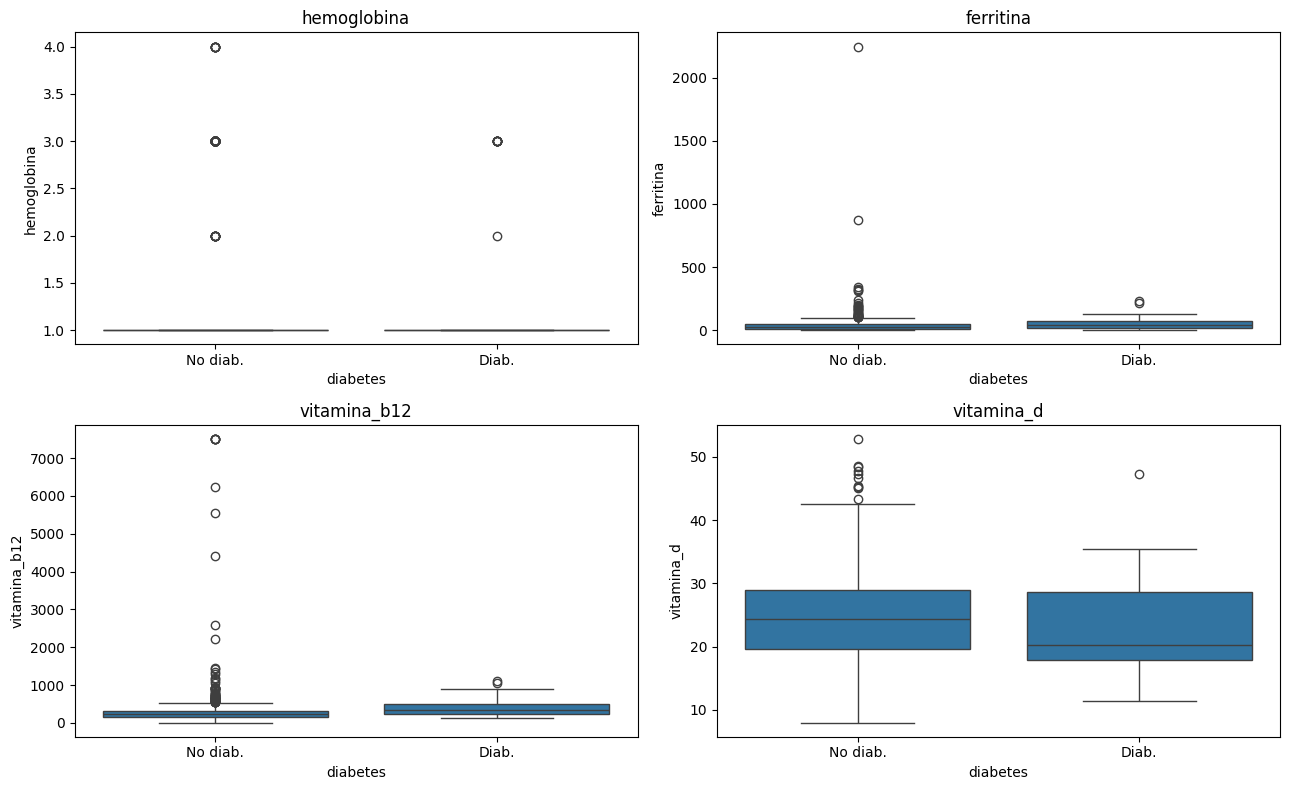

In [65]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, col in zip(axes.flat, ['hemoglobina','ferritina','vitamina_b12','vitamina_d']):
    sns.boxplot(data=proc_e, x='diabetes', y=col, ax=ax)
    ax.set_title(col); ax.set_xticklabels(['No diab.', 'Diab.'])
plt.tight_layout(); plt.show()


En las gráficas se puede notar que ferritina y la vitamina b12, tiene valores ligeramente mas altos en personas con diabetes. En la vitamina d se puede que es un poco mas baja.

### Actividad fisica por clase


/tmp/ipykernel_583/184571362.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_title(col); ax.set_xticklabels(['No diab.', 'Diab.'])
/tmp/ipykernel_583/184571362.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_title(col); ax.set_xticklabels(['No diab.', 'Diab.'])
/tmp/ipykernel_583/184571362.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_title(col); ax.set_xticklabels(['No diab.', 'Diab.'])


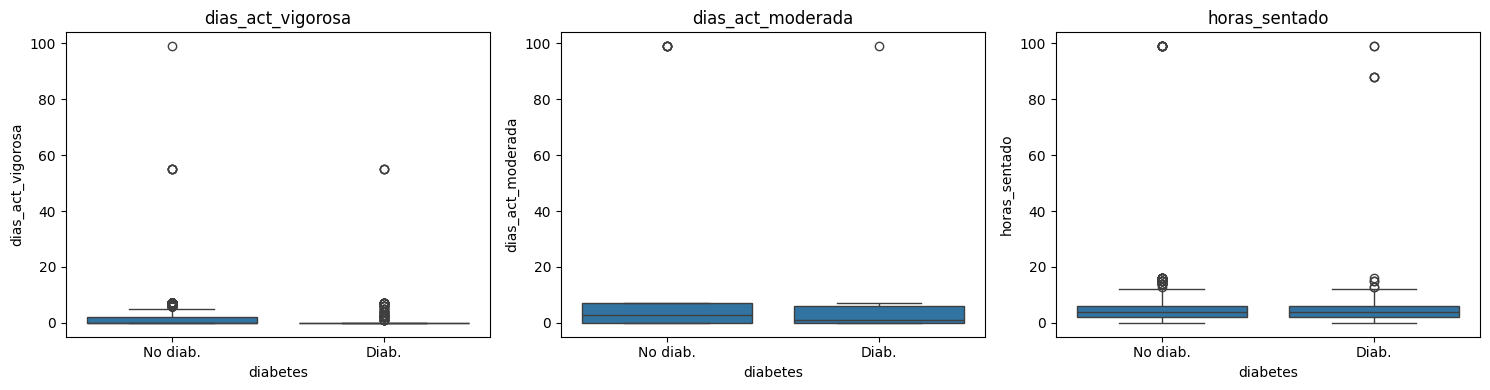

In [66]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['dias_act_vigorosa','dias_act_moderada','horas_sentado']):
    sns.boxplot(data=proc_e, x='diabetes', y=col, ax=ax)
    ax.set_title(col); ax.set_xticklabels(['No diab.', 'Diab.'])
plt.tight_layout(); plt.show()


En la gráfica se puede notar que las personas con diabetes suelen tener menor actividad fisica.


### Correlacion de las variables nuevas con la diabetes


In [68]:
nuevas = [
    'horas_sueno', 'dias_act_vigorosa', 'dias_act_moderada', 'dias_caminata',
    'horas_sentado', 'hemoglobina', 'ferritina', 'vitamina_b12', 'vitamina_d'
]
corr = proc_e[nuevas + ['diabetes']].corr()['diabetes'].drop('diabetes')
corr_orden = corr.abs().sort_values(ascending=False).index
print('Correlacion (Pearson) con la variable diabetes:')
print(corr.loc[corr_orden].round(3))

Correlacion (Pearson) con la variable diabetes:
dias_caminata       -0.054
horas_sentado        0.045
vitamina_d          -0.045
ferritina            0.036
horas_sueno          0.034
hemoglobina         -0.029
dias_act_moderada   -0.021
vitamina_b12         0.017
dias_act_vigorosa   -0.009
Name: diabetes, dtype: float64


### Paso 20. Guardar el dataset enriquecido


In [69]:
proc_e.to_csv('mineria_enriquecido.csv', index=False)